# **Day 74: Graph Neural Networks (GNNs)**
*Module 11 - Advanced Deep Learning*

Many data are **graphs**: road and river networks, social networks, molecules, power grids, citation networks, and spatial data where nearby locations influence each other (fields and their neighbours, weather stations, river gauges along a network). Grids (images) and sequences are special cases of graphs. **Graph neural networks** learn from node features **and** connectivity.

> Graph neural networks learn from data organised as nodes and connections, passing messages between neighbours. They suit road networks, river networks, social networks and molecules.
>
> *Example:* Predicting traffic at each junction of a city road network: each junction's prediction uses information from its connected neighbours.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(74); rng = np.random.default_rng(74)

## **1. Graph Basics**
A graph $G = (V, E)$ with $n$ nodes; **adjacency matrix** $A_{ij} = 1$ if nodes $i$ and $j$ are connected; **degree** $d_i = \sum_jA_{ij}$; node features $X\in\mathbb R^{n\times p}$.

34 nodes, 78 edges | degrees: min 3, max 48


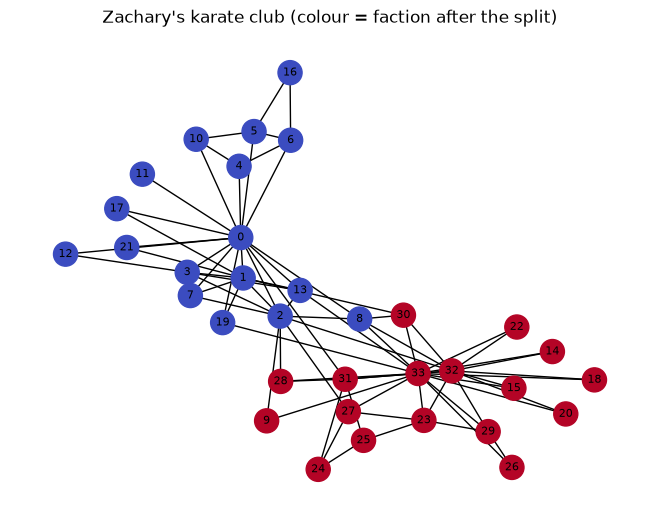

In [2]:
Gk = nx.karate_club_graph()                                     # a classic social network: a club that split into two factions
A_k = nx.to_numpy_array(Gk); y_k = np.array([0 if Gk.nodes[i]["club"] == "Mr. Hi" else 1 for i in Gk])
print(f"{Gk.number_of_nodes()} nodes, {Gk.number_of_edges()} edges | degrees: min {A_k.sum(1).min():.0f}, max {A_k.sum(1).max():.0f}")
pos = nx.spring_layout(Gk, seed=1)
nx.draw(Gk, pos, node_color=y_k, cmap="coolwarm", with_labels=True, node_size=300, font_size=8); plt.title("Zachary's karate club (colour = faction after the split)"); plt.show()

## **2. Message Passing and the GCN Layer**
Each layer updates every node from its neighbours:
$$\mathbf h_v^{(l+1)} = \sigma\Big(W^{(l)}\cdot\text{AGG}\big(\{\mathbf h_u^{(l)} : u\in\mathcal N(v)\cup\{v\}\}\big)\Big)$$
The **GCN** uses a normalised sum: $H^{(l+1)} = \sigma\big(\hat D^{-1/2}\hat A\hat D^{-1/2}H^{(l)}W^{(l)}\big)$ with $\hat A = A + I$ (self-loops). After $L$ layers, each node "sees" its $L$-hop neighbourhood. It is a convolution on a graph: weights are shared across nodes, like a CNN kernel shared across pixels.

In [3]:
def normalised_adjacency(A):
    A_hat = A + np.eye(len(A)); d = A_hat.sum(1)
    return torch.tensor(A_hat / np.sqrt(np.outer(d, d)), dtype=torch.float32)

class GCNLayer(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__(); self.lin = nn.Linear(d_in, d_out)
    def forward(self, x, A_norm):
        return A_norm @ self.lin(x)                         # transform features, then aggregate over neighbours

class GCN(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, n_layers=2, dropout=0.5):
        super().__init__(); dims = [d_in] + [d_hidden] * (n_layers - 1) + [d_out]
        self.layers = nn.ModuleList([GCNLayer(a, b) for a, b in zip(dims[:-1], dims[1:])]); self.dropout = dropout
    def forward(self, x, A_norm, return_hidden=False):
        for i, layer in enumerate(self.layers):
            x = layer(F.dropout(x, self.dropout, self.training), A_norm)
            if i < len(self.layers) - 1:
                x = F.relu(x); hidden = x
        return (x, hidden) if return_hidden else x

### Semi-supervised node classification on the karate club
Only **two** labelled nodes (the two leaders). Node features: identity (one-hot), i.e. no information except the graph structure.

accuracy on the 32 unlabelled members (from 2 labels + the graph): 0.967


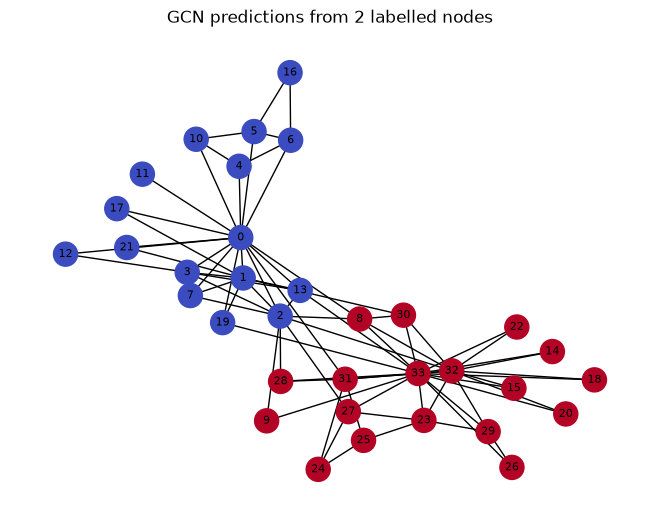

In [4]:
A_norm = normalised_adjacency(A_k); X_id = torch.eye(34); y_t = torch.tensor(y_k)
train_idx = torch.tensor([0, 33])
gcn = GCN(34, 16, 2, dropout=0.3); opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
for epoch in range(200):
    gcn.train(); loss = F.cross_entropy(gcn(X_id, A_norm)[train_idx], y_t[train_idx]); opt.zero_grad(); loss.backward(); opt.step()
gcn.eval(); pred = gcn(X_id, A_norm).argmax(1)
print(f"accuracy on the 32 unlabelled members (from 2 labels + the graph): {(pred == y_t).float()[2:32].mean():.3f}")
nx.draw(Gk, pos, node_color=pred.numpy(), cmap="coolwarm", with_labels=True, node_size=300, font_size=8); plt.title("GCN predictions from 2 labelled nodes"); plt.show()

## **3. A Spatial Graph: Field-Level Crop Classification With Neighbourhood Context**
Fields in a region form a graph (edges between neighbouring fields). Neighbouring fields often grow the same crop (irrigation command areas, soils, farmer practices): **spatial autocorrelation of labels**. A GCN can exploit it on top of each field's own (noisy) spectral features.

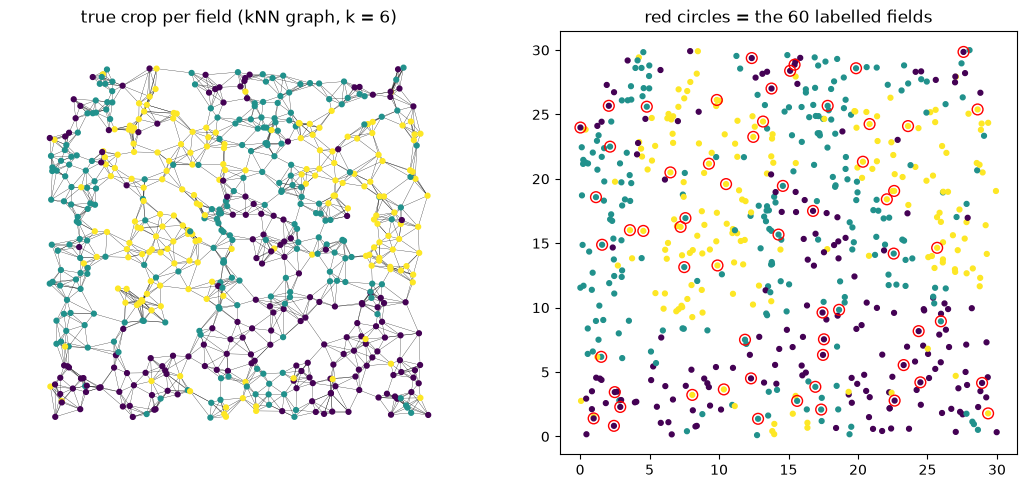

In [5]:
n_fields = 600
coords = rng.uniform(0, 30, (n_fields, 2))                                             # field centroids (km)
from scipy.ndimage import gaussian_filter
zone_field = gaussian_filter(rng.normal(size=(60, 60)), 6)
zone = np.digitize(zone_field[(coords[:, 1] * 2).astype(int).clip(0, 59), (coords[:, 0] * 2).astype(int).clip(0, 59)], np.quantile(zone_field, [0.33, 0.66]))
crop = np.where(rng.random(n_fields) < 0.8, zone, rng.integers(0, 3, n_fields))          # 80% follow the local zone
class_means = np.array([[0.6, 0.2, 0.1, 0.4], [0.3, 0.5, 0.3, 0.2], [0.2, 0.3, 0.6, 0.5]])
feats = class_means[crop] + rng.normal(0, 0.28, (n_fields, 4))                         # noisy per-field features
from sklearn.neighbors import kneighbors_graph
A_s = kneighbors_graph(coords, 6, mode="connectivity").toarray(); A_s = np.maximum(A_s, A_s.T)
A_s_norm = normalised_adjacency(A_s)
Xf, yf = torch.tensor(feats, dtype=torch.float32), torch.tensor(crop)
perm = rng.permutation(n_fields); tr, va, te = torch.tensor(perm[:60]), torch.tensor(perm[60:160]), torch.tensor(perm[160:])   # only 60 labelled fields

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
Gs = nx.from_numpy_array(A_s); p_s = {i: coords[i] for i in range(n_fields)}
nx.draw(Gs, p_s, node_color=crop, cmap="viridis", node_size=12, width=0.2, ax=axes[0]); axes[0].set_title("true crop per field (kNN graph, k = 6)")
axes[1].scatter(*coords.T, c=crop, cmap="viridis", s=12); axes[1].scatter(*coords[perm[:60]].T, facecolors="none", edgecolors="r", s=60); axes[1].set_title("red circles = the 60 labelled fields")
plt.show()

In [6]:
def train_node_model(model, X_, A_, epochs=300):
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4); best, best_state = 0, None
    for ep in range(epochs):
        model.train(); out = model(X_, A_); loss = F.cross_entropy(out[tr], yf[tr]); opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); va_acc = (model(X_, A_).argmax(1)[va] == yf[va]).float().mean().item()
        if va_acc >= best: best, best_state = va_acc, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state); model.eval()
    return (model(X_, A_).argmax(1)[te] == yf[te]).float().mean().item()

torch.manual_seed(0)
results = {"MLP (own features only, A = I)": train_node_model(GCN(4, 32, 3), Xf, torch.eye(n_fields)),
           "GCN, 1 layer (1-hop context)": train_node_model(GCN(4, 32, 3, n_layers=1), Xf, A_s_norm),
           "GCN, 2 layers (2-hop context)": train_node_model(GCN(4, 32, 3, n_layers=2), Xf, A_s_norm)}
from sklearn.ensemble import RandomForestClassifier
results["Random Forest (own features)"] = RandomForestClassifier(300, random_state=0).fit(feats[perm[:60]], crop[perm[:60]]).score(feats[perm[160:]], crop[perm[160:]])
neigh_mean = (A_s / A_s.sum(1, keepdims=True)) @ feats                                  # hand-made spatial feature: neighbour average
results["Random Forest (own + neighbour-mean features)"] = RandomForestClassifier(300, random_state=0).fit(np.c_[feats, neigh_mean][perm[:60]], crop[perm[:60]]).score(np.c_[feats, neigh_mean][perm[160:]], crop[perm[160:]])
pd.Series(results, name="test accuracy (60 labelled fields)").round(3)

MLP (own features only, A = I)                   0.620
GCN, 1 layer (1-hop context)                     0.714
GCN, 2 layers (2-hop context)                    0.736
Random Forest (own features)                     0.625
Random Forest (own + neighbour-mean features)    0.693
Name: test accuracy (60 labelled fields), dtype: float64

Spatial context helps a lot when labels are spatially autocorrelated. (Note: this also means **random** splits of neighbouring fields can leak information, Day 88.)

## **4. Other Aggregators: GraphSAGE and Graph Attention**
- **GraphSAGE** (Hamilton et al., 2017): concatenate a node's own state with the **mean/max of a sampled set** of neighbours: scales to huge graphs and generalises to unseen nodes (inductive).
- **GAT** (Velickovic et al., 2018): learn **attention weights** over neighbours, so important neighbours count more (Day 67 on graphs).

In [7]:
class SAGELayer(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__(); self.self_lin, self.neigh_lin = nn.Linear(d_in, d_out), nn.Linear(d_in, d_out)
    def forward(self, x, A_mean):
        return self.self_lin(x) + self.neigh_lin(A_mean @ x)             # own state + mean of neighbours
class SAGE(nn.Module):
    def __init__(self, d_in, d_h, d_out):
        super().__init__(); self.l1, self.l2 = SAGELayer(d_in, d_h), SAGELayer(d_h, d_out)
    def forward(self, x, A_mean):
        return self.l2(F.dropout(F.relu(self.l1(x, A_mean)), 0.3, self.training), A_mean)
A_mean = torch.tensor(A_s / A_s.sum(1, keepdims=True), dtype=torch.float32)
torch.manual_seed(0); print("GraphSAGE (mean aggregator) test accuracy:", round(train_node_model(SAGE(4, 32, 3), Xf, A_mean), 3))

GraphSAGE (mean aggregator) test accuracy: 0.723


# **Part 2: Going Deeper - Over-Smoothing**

Each GCN layer averages neighbours. With many layers, every node's representation converges to the same vector: **over-smoothing**. That is why GNNs are usually shallow (2-4 layers), or use residual connections / jumping knowledge.

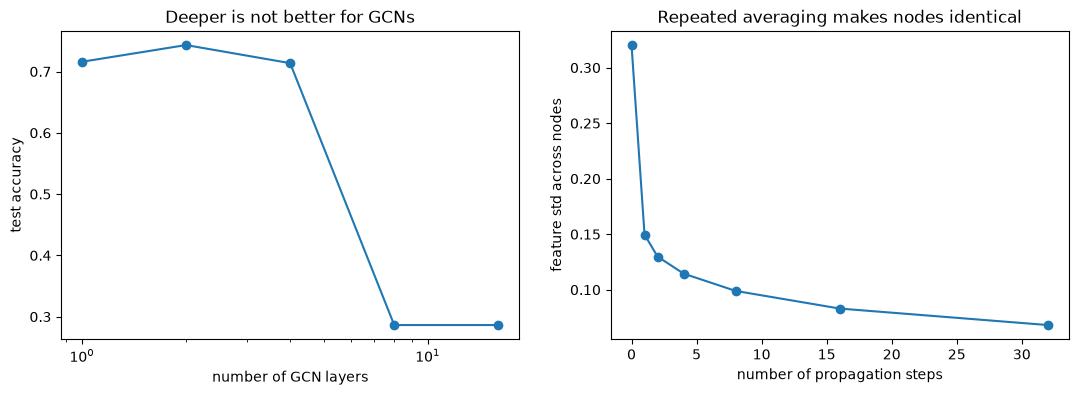

In [8]:
accs = {}
for L in [1, 2, 4, 8, 16]:
    torch.manual_seed(0); accs[L] = train_node_model(GCN(4, 32, 3, n_layers=L, dropout=0.2), Xf, A_s_norm, epochs=300)
H = Xf.clone(); spread = []
for k in range(33):
    if k in (0, 1, 2, 4, 8, 16, 32): spread.append((k, H.std(0).mean().item()))
    H = A_s_norm @ H
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(accs), list(accs.values()), "o-"); axes[0].set(xscale="log", xlabel="number of GCN layers", ylabel="test accuracy", title="Deeper is not better for GCNs")
axes[1].plot(*zip(*spread), "o-"); axes[1].set(xlabel="number of propagation steps", ylabel="feature std across nodes", title="Repeated averaging makes nodes identical")
plt.show()

### Beyond node classification
- **Link prediction**: will two nodes connect? (recommendations, road network completion)
- **Graph classification**: one label per graph (molecule toxicity) using a readout (sum/mean pooling of node states).
- **Spatio-temporal GNNs**: graphs whose node features are time series: traffic, river discharge along a river network, air-quality stations; GraphCast (Lam et al., 2023) forecasts global weather with message passing on a multi-mesh over the Earth.
- Libraries: **PyTorch Geometric** and **DGL** provide efficient sparse message passing, sampling and dozens of layer types.

```python
# PyTorch Geometric equivalent of our 2-layer GCN (pip install torch_geometric)
from torch_geometric.nn import GCNConv
class GCN_PyG(torch.nn.Module):
    def __init__(self, d_in, d_h, d_out):
        super().__init__(); self.c1, self.c2 = GCNConv(d_in, d_h), GCNConv(d_h, d_out)
    def forward(self, x, edge_index):                     # edge_index: (2, n_edges) sparse connectivity
        return self.c2(F.relu(self.c1(x, edge_index)), edge_index)
```

## **Practice Problems**
1. Change k in the k-nearest-neighbour graph (3, 6, 15). How does GCN accuracy change?
2. Replace the connectivity weights by **distance-decay** weights $w_{ij} = e^{-d_{ij}/\lambda}$ and retrain the GCN.
3. Visualise the GCN's hidden representations (2-D PCA) for the karate club. Are the two factions separated?
4. *(Advanced)* Implement a single-head **graph attention** layer: $e_{ij} = \text{LeakyReLU}(\mathbf a^\top[W\mathbf h_i\,\|\,W\mathbf h_j])$, softmax over neighbours, weighted sum. Train it on the field graph.

k =  3: GCN accuracy 0.739


k = 15: GCN accuracy 0.689


distance-decay weighted GCN: 0.711


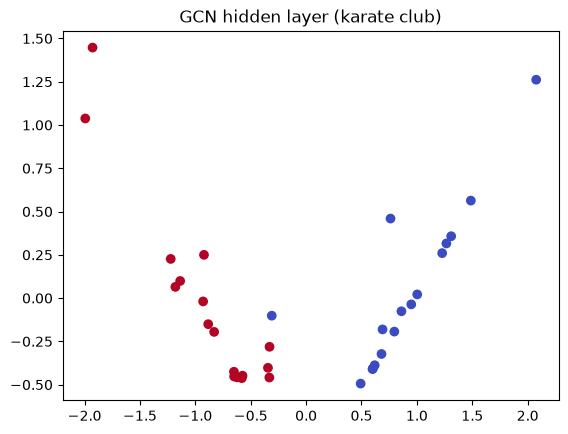

graph attention network: 0.677


In [9]:
# Solution 1
for k in [3, 15]:
    Ak = kneighbors_graph(coords, k).toarray(); Ak = np.maximum(Ak, Ak.T); torch.manual_seed(0)
    print(f"k = {k:>2}: GCN accuracy {train_node_model(GCN(4, 32, 3), Xf, normalised_adjacency(Ak)):.3f}")
# Solution 2
D = np.linalg.norm(coords[:, None] - coords[None], axis=2); W = np.exp(-D / 1.5) * (D < 4); np.fill_diagonal(W, 0)
torch.manual_seed(0); print("distance-decay weighted GCN:", round(train_node_model(GCN(4, 32, 3), Xf, normalised_adjacency(W)), 3))
# Solution 3
from sklearn.decomposition import PCA
_, hid = gcn(X_id, A_norm, return_hidden=True)
Z = PCA(2).fit_transform(hid.detach().numpy()); plt.scatter(*Z.T, c=y_k, cmap="coolwarm"); plt.title("GCN hidden layer (karate club)"); plt.show()
# Solution 4
class GATLayer(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__(); self.W = nn.Linear(d_in, d_out, bias=False); self.a = nn.Linear(2 * d_out, 1, bias=False)
    def forward(self, x, A):
        h = self.W(x); n = len(h)
        e = F.leaky_relu(self.a(torch.cat([h.unsqueeze(1).expand(n, n, -1), h.unsqueeze(0).expand(n, n, -1)], -1)).squeeze(-1), 0.2)
        e = e.masked_fill((A + torch.eye(n)) == 0, float("-inf")); return torch.softmax(e, 1) @ h
class GAT(nn.Module):
    def __init__(self):
        super().__init__(); self.l1, self.l2 = GATLayer(4, 32), GATLayer(32, 3)
    def forward(self, x, A): return self.l2(F.elu(self.l1(x, A)), A)
torch.manual_seed(0); print("graph attention network:", round(train_node_model(GAT(), Xf, torch.tensor(A_s, dtype=torch.float32), epochs=150), 3))

## **Key References**
- Kipf, T. N., & Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR 2017*.
- Hamilton, W. L., Ying, R., & Leskovec, J. (2017). Inductive representation learning on large graphs. *NeurIPS 30* (GraphSAGE).
- Velickovic, P. et al. (2018). Graph attention networks. *ICLR 2018*.
- Gilmer, J., Schoenholz, S. S., Riley, P. F., Vinyals, O., & Dahl, G. E. (2017). Neural message passing for quantum chemistry. *ICML 2017*.
- Li, Q., Han, Z., & Wu, X.-M. (2018). Deeper insights into graph convolutional networks for semi-supervised learning. *AAAI 2018* (over-smoothing).
- Lam, R. et al. (2023). Learning skillful medium-range global weather forecasting. *Science*, 382(6677), 1416-1421 (GraphCast).
- Fey, M., & Lenssen, J. E. (2019). Fast graph representation learning with PyTorch Geometric. *ICLR Workshop on Representation Learning on Graphs and Manifolds*.